In [19]:
import torch
print("Torch version:", torch.__version__)              #Basicamente en un entorno virtual echo con anaconda, 
print("CUDA disponible:", torch.cuda.is_available())    #se usa python 3.11.15, y se necesita tener pytorch instalado con sus depedencias de CUDA correspondientes
print("CUDA version compilada:", torch.version.cuda)    #prints comentados por si se quiere revisar resultados de algun bloque de codigo

if torch.cuda.is_available():
    print("GPU disponible:", torch.cuda.get_device_name(0))
else: 
    print("Algo ha ido mal. No se ha detectado GPU compatible con CUDA")
    
#S1: "My voice is my Password"
#S2: "Okay Miguel"
#S3: "Artificial intelligence is for real"
#S4: "Actions speak louder than words"
#S5: "There is no such thing as a free lunch"


   
import librosa      #para cargar el audio
import os           #para moverme entre directorios usando el S.O.
import matplotlib.pyplot as plt   #para visualizar el audio

Torch version: 2.11.0+cu128
CUDA disponible: True
CUDA version compilada: 12.8
GPU disponible: NVIDIA GeForce RTX 2060


In [ ]:
#esta parte de código es un ejemplo de como convertir un archivo de audio en un espectograma MFCC
waveform, sr = librosa.load("Database/S1/spk_000001/trn_043467.wav", sr=16000)
print(waveform.shape)
print(sr)
mfcc = librosa.feature.mfcc(
    y=waveform,
    sr=sr,
    n_mfcc=40
)

print(mfcc.shape)
import matplotlib.pyplot as plt

plt.imshow( mfcc, aspect='auto', origin='lower')

plt.colorbar()

plt.show()

(46080,)
16000


In [ ]:
#Esta parte de codigo recorre la base de datos

dirRaiz = "Database" # He llamado a la carpeta sacada del zip "database"

for frase in os.listdir(dirRaiz):                           #recorro database -> s1, s2, s3, s4, s5
    pathFrase = os.path.join(dirRaiz,frase)     

    for locutor in os.listdir(pathFrase):                   #recorro carpetas spk_000001 ...
        locutorPath = os.path.join( pathFrase, locutor)

        for archivo in os.listdir(locutorPath):             #recorro los archivos de audio .wav
            pathArchivo = os.path.join(locutorPath, archivo)
                  
            #print(pathArchivo)
            #print("Frase:", frase)
            #print("Locutor:", locutor)
            #print()

Database\S1\spk_000001\trn_043467.wav
Frase: S1
Locutor: spk_000001

Database\S1\spk_000001\trn_043468.wav
Frase: S1
Locutor: spk_000001

Database\S1\spk_000001\trn_043469.wav
Frase: S1
Locutor: spk_000001

Database\S1\spk_000001\trn_043470.wav
Frase: S1
Locutor: spk_000001

Database\S1\spk_000001\trn_043471.wav
Frase: S1
Locutor: spk_000001

Database\S1\spk_000001\trn_043472.wav
Frase: S1
Locutor: spk_000001

Database\S1\spk_000001\trn_043473.wav
Frase: S1
Locutor: spk_000001

Database\S1\spk_000001\trn_043474.wav
Frase: S1
Locutor: spk_000001

Database\S1\spk_000002\trn_010648.wav
Frase: S1
Locutor: spk_000002

Database\S1\spk_000002\trn_010649.wav
Frase: S1
Locutor: spk_000002

Database\S1\spk_000002\trn_010650.wav
Frase: S1
Locutor: spk_000002

Database\S1\spk_000002\trn_010651.wav
Frase: S1
Locutor: spk_000002

Database\S1\spk_000002\trn_010652.wav
Frase: S1
Locutor: spk_000002

Database\S1\spk_000002\trn_010653.wav
Frase: S1
Locutor: spk_000002

Database\S1\spk_000002\trn_010654.

In [ ]:
#aquí crearé un mapa de etiquetas para los locutores
locutoresMap = {}
cont = 0
for frase in os.listdir(dirRaiz):
    frasePath = os.path.join(dirRaiz, frase)

    for locutor in os.listdir(frasePath):
        if locutor not in locutoresMap:
            locutoresMap[locutor] = cont
            cont += 1  
#print(locutoresMap) 

{'spk_000001': 0, 'spk_000002': 1, 'spk_000003': 2, 'spk_000004': 3, 'spk_000005': 4, 'spk_000006': 5, 'spk_000007': 6, 'spk_000008': 7, 'spk_000010': 8, 'spk_000011': 9, 'spk_000012': 10, 'spk_000013': 11, 'spk_000014': 12, 'spk_000015': 13, 'spk_000016': 14, 'spk_000017': 15, 'spk_000018': 16, 'spk_000019': 17, 'spk_000020': 18, 'spk_000021': 19, 'spk_000023': 20, 'spk_000024': 21, 'spk_000025': 22, 'spk_000026': 23, 'spk_000027': 24, 'spk_000028': 25, 'spk_000029': 26, 'spk_000030': 27, 'spk_000031': 28, 'spk_000032': 29, 'spk_000033': 30, 'spk_000034': 31, 'spk_000035': 32, 'spk_000037': 33, 'spk_000038': 34, 'spk_000039': 35, 'spk_000040': 36, 'spk_000041': 37, 'spk_000042': 38, 'spk_000043': 39, 'spk_000044': 40, 'spk_000045': 41, 'spk_000046': 42, 'spk_000047': 43, 'spk_000048': 44, 'spk_000049': 45, 'spk_000050': 46, 'spk_000051': 47, 'spk_000052': 48, 'spk_000053': 49, 'spk_000054': 50, 'spk_000055': 51, 'spk_000056': 52, 'spk_000057': 53, 'spk_000058': 54, 'spk_000059': 55, '

In [ ]:
#aquí creo un mapa de etiquetas para las frases
fraseMap = {}
cont = 0
for frase in os.listdir(dirRaiz):
    if frase not in fraseMap:
        fraseMap[frase] = cont
        cont += 1
#print(fraseMap)

{'S1': 0, 'S2': 1, 'S3': 2, 'S4': 3, 'S5': 4}


In [17]:
#en esta parte cargaré el audio
waveform, sr = librosa.load(pathArchivo, sr=16000)
print(waveform.shape)
print(sr)
mfcc = librosa.feature.mfcc(y=waveform, sr=sr, n_mfcc=40)

print(mfcc.shape)

(83840,)
16000
(40, 164)


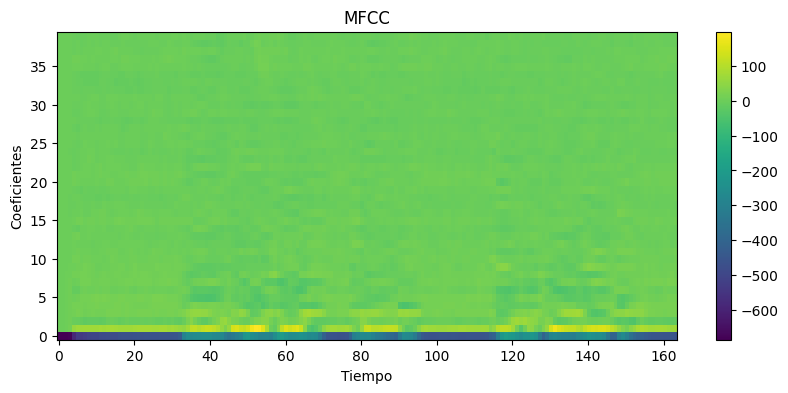

In [21]:
#aquí visualizo el audio
from matplotlib.pyplot import imshow
plt.figure(figsize=(10,4))
plt.imshow(mfcc, aspect = 'auto', origin = 'lower')
plt.title("MFCC")
plt.xlabel("Tiempo")
plt.ylabel("Coeficientes")
plt.colorbar()
plt.show()